# 03 Baseline U-Net Reproduction

This notebook starts the modeling phase of the glaucoma segmentation workflow.

The purpose of this notebook is to reproduce a simple baseline U-Net-style segmentation experiment using the combined split-aware manifest produced by Notebook `02`.

This notebook should answer:

1. Can the combined split manifest from Notebook `02` be loaded without redoing the split workflow?
2. Can train/validation/test dataloaders be built from the combined manifest?
3. Can a baseline U-Net model be constructed from project source code?
4. Can the project loss, metrics, device, seed, and training loop utilities support a minimal training smoke test?
5. Is the baseline U-Net workflow ready to scale into longer training experiments?

This notebook intentionally does **not** compare architectures, tune augmentations, run offline synthetic expansion, or evaluate final holdout performance. Those steps belong in later notebooks.

In [1]:
# 03.01 — Imports

from pathlib import Path
import importlib
import inspect
import json
import os
import platform
import sys
from datetime import datetime

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [2]:
# 03.02 — Project root and source path setup

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 100)


def find_project_root(start_path: Path | None = None) -> Path:
    """
    Walk upward from the current location until the project root is found.

    The project root is identified by the presence of:
    - README.md
    - configs/
    - src/
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for candidate in [start_path, *start_path.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "configs").exists()
            and (candidate / "src").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate project root. Expected README.md, configs/, and src/."
    )


PROJECT_ROOT = find_project_root()
SRC_PATH = PROJECT_ROOT / "src"

os.chdir(PROJECT_ROOT)

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

PROJECT_ROOT, SRC_PATH

(PosixPath('/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy'),
 PosixPath('/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy/src'))

In [3]:
# 03.03 — Environment and phase-03 directory setup

DATA_ROOT = PROJECT_ROOT / "data"
MANIFEST_DIR = DATA_ROOT / "processed" / "manifests"
REPORTS_DIR = PROJECT_ROOT / "reports"
TRAINING_REPORT_DIR = REPORTS_DIR / "training"
FIGURES_DIR = REPORTS_DIR / "figures"

for directory in [TRAINING_REPORT_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

environment_df = pd.DataFrame(
    [
        {
            "check": "Project root",
            "status": "OK" if PROJECT_ROOT.exists() else "CHECK",
            "value": str(PROJECT_ROOT),
        },
        {
            "check": "Notebook Python executable",
            "status": "OK" if "glaucoma-capstone" in sys.executable else "CHECK",
            "value": sys.executable,
        },
        {
            "check": "Python version",
            "status": "OK",
            "value": sys.version.replace("\n", " "),
        },
        {
            "check": "PyTorch version",
            "status": "OK",
            "value": torch.__version__,
        },
        {
            "check": "CUDA availability",
            "status": "OK" if torch.cuda.is_available() else "CPU_ONLY",
            "value": f"CUDA device count: {torch.cuda.device_count()}",
        },
        {
            "check": "Training report directory",
            "status": "OK" if TRAINING_REPORT_DIR.exists() else "CHECK",
            "value": str(TRAINING_REPORT_DIR.relative_to(PROJECT_ROOT)),
        },
        {
            "check": "Figures directory",
            "status": "OK" if FIGURES_DIR.exists() else "CHECK",
            "value": str(FIGURES_DIR.relative_to(PROJECT_ROOT)),
        },
    ]
)

environment_df

,check,status,value
0,Project root,OK,/sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy
1,Notebook Python executable,OK,/home/gsr3qz/.conda/envs/glaucoma-capstone/bin/python
2,Python version,OK,"3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:34:02) [GCC 14.3.0]"
3,PyTorch version,OK,2.4.0
4,CUDA availability,OK,CUDA device count: 1
5,Training report directory,OK,reports/training
6,Figures directory,OK,reports/figures


In [4]:
# 03.04 — Input manifest handoff verification

COMBINED_MANIFEST_PATH = MANIFEST_DIR / "combined_segmentation_manifest_with_splits.csv"

if not COMBINED_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "Combined split manifest not found. Run Notebook 02 before Notebook 03. "
        f"Expected: {COMBINED_MANIFEST_PATH}"
    )

manifest = pd.read_csv(COMBINED_MANIFEST_PATH)

required_columns = {"image_path", "mask_path", "split", "dataset_key", "source_dataset"}
missing_columns = required_columns - set(manifest.columns)

if missing_columns:
    raise ValueError(
        f"Combined manifest is missing required columns: {sorted(missing_columns)}"
    )

handoff_check_df = pd.DataFrame(
    [
        {
            "check": "Combined split manifest exists",
            "status": "OK",
            "value": str(COMBINED_MANIFEST_PATH.relative_to(PROJECT_ROOT)),
        },
        {
            "check": "Manifest rows",
            "status": "OK" if len(manifest) > 0 else "CHECK",
            "value": len(manifest),
        },
        {
            "check": "Required columns",
            "status": "OK",
            "value": ", ".join(sorted(required_columns)),
        },
    ]
)

handoff_check_df

,check,status,value
0,Combined split manifest exists,OK,data/processed/manifests/combined_segmentation_manifest_with_splits.csv
1,Manifest rows,OK,3358
2,Required columns,OK,"dataset_key, image_path, mask_path, source_dataset, split"


In [5]:
# 03.05 — Core project module import check

from glaucoma_segmentation.data.dataloaders import (
    SegmentationDataLoaders,
    make_segmentation_dataloaders,
)
from glaucoma_segmentation.nets.losses import DiceCELoss
from glaucoma_segmentation.nets.model_factory import build_model
from glaucoma_segmentation.training.train_loop import (
    EpochResult,
    fit_model,
    history_to_dicts,
    run_one_epoch,
)
from glaucoma_segmentation.utils.device import describe_device, device_summary_dict, get_device
from glaucoma_segmentation.utils.seed import seed_everything

module_checks = [
    {
        "module": "glaucoma_segmentation.data.dataloaders",
        "object": "make_segmentation_dataloaders",
        "status": "OK" if callable(make_segmentation_dataloaders) else "CHECK",
    },
    {
        "module": "glaucoma_segmentation.nets.model_factory",
        "object": "build_model",
        "status": "OK" if callable(build_model) else "CHECK",
    },
    {
        "module": "glaucoma_segmentation.nets.losses",
        "object": "DiceCELoss",
        "status": "OK" if inspect.isclass(DiceCELoss) else "CHECK",
    },
    {
        "module": "glaucoma_segmentation.training.train_loop",
        "object": "fit_model",
        "status": "OK" if callable(fit_model) else "CHECK",
    },
    {
        "module": "glaucoma_segmentation.utils.device",
        "object": "get_device",
        "status": "OK" if callable(get_device) else "CHECK",
    },
    {
        "module": "glaucoma_segmentation.utils.seed",
        "object": "seed_everything",
        "status": "OK" if callable(seed_everything) else "CHECK",
    },
]

module_check_df = pd.DataFrame(module_checks)
module_check_df

/home/gsr3qz/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,module,object,status
0,glaucoma_segmentation.data.dataloaders,make_segmentation_dataloaders,OK
1,glaucoma_segmentation.nets.model_factory,build_model,OK
2,glaucoma_segmentation.nets.losses,DiceCELoss,OK
3,glaucoma_segmentation.training.train_loop,fit_model,OK
4,glaucoma_segmentation.utils.device,get_device,OK
5,glaucoma_segmentation.utils.seed,seed_everything,OK


In [6]:
# 03.06 — Manifest split summary

split_summary = (
    manifest.groupby(["split", "dataset_key", "source_dataset"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values(["split", "dataset_key", "source_dataset"])
    .reset_index(drop=True)
)

overall_split_summary = (
    manifest.groupby("split", dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("split")
    .reset_index(drop=True)
)

display(overall_split_summary)
display(split_summary)

,split,rows
0,test,722
1,train,1911
2,val,725


,split,dataset_key,source_dataset,rows
0,test,glaucoma_fundus_imaging_bundle,G1020,153
1,test,glaucoma_fundus_imaging_bundle,ORIGA,97
2,test,glaucoma_fundus_imaging_bundle,REFUGE,400
3,test,papila,PAPILA,72
4,train,glaucoma_fundus_imaging_bundle,G1020,714
5,train,glaucoma_fundus_imaging_bundle,ORIGA,455
6,train,glaucoma_fundus_imaging_bundle,REFUGE,400
7,train,papila,PAPILA,342
8,val,glaucoma_fundus_imaging_bundle,G1020,153
9,val,glaucoma_fundus_imaging_bundle,ORIGA,98


In [7]:
# 03.07 — Lightweight path validity check

PATH_CHECK_SAMPLE_PER_SPLIT = 20

path_check_rows = []

for split_name, split_df in manifest.groupby("split", dropna=False):
    sample_df = split_df.head(PATH_CHECK_SAMPLE_PER_SPLIT)

    for row in sample_df.itertuples(index=False):
        image_path = PROJECT_ROOT / row.image_path
        mask_path = PROJECT_ROOT / row.mask_path

        path_check_rows.append(
            {
                "split": split_name,
                "file_id": getattr(row, "file_id", None),
                "dataset_key": getattr(row, "dataset_key", None),
                "image_exists": image_path.exists(),
                "mask_exists": mask_path.exists(),
                "image_path": row.image_path,
                "mask_path": row.mask_path,
            }
        )

path_check_df = pd.DataFrame(path_check_rows)

path_check_summary = pd.DataFrame(
    [
        {
            "checked_rows": len(path_check_df),
            "missing_images": int((~path_check_df["image_exists"]).sum()),
            "missing_masks": int((~path_check_df["mask_exists"]).sum()),
            "status": "OK"
            if path_check_df["image_exists"].all() and path_check_df["mask_exists"].all()
            else "CHECK",
        }
    ]
)

display(path_check_summary)
display(path_check_df.head())

if not path_check_df["image_exists"].all() or not path_check_df["mask_exists"].all():
    display(path_check_df[(~path_check_df["image_exists"]) | (~path_check_df["mask_exists"])])
    raise FileNotFoundError("Notebook 03 lightweight path check found missing files.")

,checked_rows,missing_images,missing_masks,status
0,60,0,0,OK


,split,file_id,dataset_key,image_exists,mask_exists,image_path,mask_path
0,test,002,glaucoma_fundus_imaging_bundle,True,True,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Images/002.jpg,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Masks/002.png
1,test,006,glaucoma_fundus_imaging_bundle,True,True,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Images/006.jpg,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Masks/006.png
2,test,011,glaucoma_fundus_imaging_bundle,True,True,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Images/011.jpg,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Masks/011.png
3,test,016,glaucoma_fundus_imaging_bundle,True,True,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Images/016.jpg,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Masks/016.png
4,test,035,glaucoma_fundus_imaging_bundle,True,True,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Images/035.jpg,data/external/kaggle/glaucoma_fundus_imaging_bundle/ORIGA/Masks/035.png


In [8]:
# 03.08 — Dataloader configuration

SEED = 42
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 2
NUM_WORKERS = 0
VALIDATE_PATHS = True
VALIDATE_MASKS = True

seed_config = seed_everything(seed=SEED, deterministic=False)

dataloader_config = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "validate_paths": VALIDATE_PATHS,
    "validate_masks": VALIDATE_MASKS,
    "manifest_path": str(COMBINED_MANIFEST_PATH.relative_to(PROJECT_ROOT)),
}

pd.DataFrame([dataloader_config])

,seed,image_size,batch_size,num_workers,validate_paths,validate_masks,manifest_path
0,42,"(128, 128)",2,0,True,True,data/processed/manifests/combined_segmentation_manifest_with_splits.csv


In [9]:
# 03.09 — Build baseline dataloaders

loaders = make_segmentation_dataloaders(
    manifest_path=COMBINED_MANIFEST_PATH,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    num_workers=NUM_WORKERS,
    validate_paths=VALIDATE_PATHS,
    validate_masks=VALIDATE_MASKS,
)

if not isinstance(loaders, SegmentationDataLoaders):
    raise TypeError(f"Expected SegmentationDataLoaders, got {type(loaders)!r}")

if loaders.train is None or loaders.val is None or loaders.test is None:
    raise ValueError("Expected train, val, and test dataloaders to be available.")

loader_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "dataset_rows": len(loaders.train.dataset),
            "batches": len(loaders.train),
            "batch_size": loaders.train.batch_size,
        },
        {
            "split": "val",
            "dataset_rows": len(loaders.val.dataset),
            "batches": len(loaders.val),
            "batch_size": loaders.val.batch_size,
        },
        {
            "split": "test",
            "dataset_rows": len(loaders.test.dataset),
            "batches": len(loaders.test),
            "batch_size": loaders.test.batch_size,
        },
    ]
)

loader_summary

,split,dataset_rows,batches,batch_size
0,train,1911,956,2
1,val,725,363,2
2,test,722,361,2


In [10]:
# 03.10 — Inspect one training batch

train_batch = next(iter(loaders.train))
train_images = train_batch["image"]
train_masks = train_batch["mask"]

batch_summary = pd.DataFrame(
    [
        {
            "field": "image",
            "shape": tuple(train_images.shape),
            "dtype": str(train_images.dtype),
            "min": float(train_images.min()),
            "max": float(train_images.max()),
            "unique_values": "[continuous]",
        },
        {
            "field": "mask",
            "shape": tuple(train_masks.shape),
            "dtype": str(train_masks.dtype),
            "min": int(train_masks.min()),
            "max": int(train_masks.max()),
            "unique_values": sorted(torch.unique(train_masks).cpu().tolist()),
        },
    ]
)

batch_metadata_columns = [
    column
    for column in ["split", "dataset_key", "source_dataset", "file_id", "split_group_id"]
    if column in train_batch
]

display(batch_summary)

if batch_metadata_columns:
    display(pd.DataFrame({column: train_batch[column] for column in batch_metadata_columns}))

,field,shape,dtype,min,max,unique_values
0,image,"(2, 3, 128, 128)",torch.float32,0.0,0.976471,[continuous]
1,mask,"(2, 128, 128)",torch.int64,0.0,2.000000,"[0, 1, 2]"


,split,dataset_key,source_dataset,file_id,split_group_id
0,train,papila,PAPILA,RET089OD,PAPILA_RET089
1,train,glaucoma_fundus_imaging_bundle,REFUGE,n0092,REFUGE_train_n0092


In [11]:
# 03.11 — Device selection

device = get_device()
device_info = describe_device(device)

pd.DataFrame([device_summary_dict(device)])

,device,device_type,name,cuda_available,cuda_device_count,mps_available
0,cuda,cuda,NVIDIA RTX A6000,True,1,False


In [12]:
# 03.12 — Build baseline U-Net model

MODEL_NAME = "unet"
ENCODER_NAME = "resnet18"
ENCODER_WEIGHTS = None
IN_CHANNELS = 3
NUM_CLASSES = 3

model = build_model(
    model_name=MODEL_NAME,
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=IN_CHANNELS,
    classes=NUM_CLASSES,
    activation=None,
)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

model_summary = pd.DataFrame(
    [
        {
            "model_name": MODEL_NAME,
            "encoder_name": ENCODER_NAME,
            "encoder_weights": ENCODER_WEIGHTS,
            "in_channels": IN_CHANNELS,
            "classes": NUM_CLASSES,
            "total_parameters": total_parameters,
            "trainable_parameters": trainable_parameters,
        }
    ]
)

model_summary

,model_name,encoder_name,encoder_weights,in_channels,classes,total_parameters,trainable_parameters
0,unet,resnet18,None,3,3,14328499,14328499


In [13]:
# 03.13 — Loss, optimizer, and metric setup

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
DICE_WEIGHT = 1.0
CE_WEIGHT = 1.0

criterion = DiceCELoss(
    dice_weight=DICE_WEIGHT,
    ce_weight=CE_WEIGHT,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

training_setup_df = pd.DataFrame(
    [
        {
            "loss": criterion.__class__.__name__,
            "dice_weight": DICE_WEIGHT,
            "ce_weight": CE_WEIGHT,
            "optimizer": optimizer.__class__.__name__,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
        }
    ]
)

training_setup_df

,loss,dice_weight,ce_weight,optimizer,learning_rate,weight_decay
0,DiceCELoss,1.0,1.0,AdamW,0.0001,0.0001


In [14]:
# 03.14 — Training smoke-test configuration

SMOKE_EPOCHS = 1
MAX_TRAIN_BATCHES = 3
MAX_VAL_BATCHES = 2

smoke_test_config = {
    "epochs": SMOKE_EPOCHS,
    "max_train_batches": MAX_TRAIN_BATCHES,
    "max_val_batches": MAX_VAL_BATCHES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "device": str(device),
    "note": "Small smoke test only; not final model training.",
}

pd.DataFrame([smoke_test_config])

,epochs,max_train_batches,max_val_batches,image_size,batch_size,device,note
0,1,3,2,"(128, 128)",2,cuda,Small smoke test only; not final model training.


In [15]:
# 03.15 — Run baseline training smoke test

history = fit_model(
    model=model,
    train_loader=loaders.train,
    val_loader=loaders.val,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=SMOKE_EPOCHS,
    max_train_batches=MAX_TRAIN_BATCHES,
    max_val_batches=MAX_VAL_BATCHES,
)

history_df = pd.DataFrame(history_to_dicts(history))
history_df

,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches
0,train,1,1.697156,7.357064e-02,1.453623e-02,0.465337,6,3,1.338819,3
1,val,1,1.776657,3.788545e-09,5.690877e-09,0.467407,4,2,0.382367,2


In [16]:
# 03.16 — Save training smoke-test summary

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

training_summary_path = TRAINING_REPORT_DIR / "baseline_unet_smoke_test_summary.csv"
training_config_path = TRAINING_REPORT_DIR / "baseline_unet_smoke_test_config.json"

history_df.to_csv(training_summary_path, index=False)

training_config = {
    "timestamp": timestamp,
    "manifest_path": str(COMBINED_MANIFEST_PATH.relative_to(PROJECT_ROOT)),
    "seed_config": seed_config.__dict__,
    "dataloader_config": {
        **dataloader_config,
        "image_size": list(IMAGE_SIZE),
    },
    "device": device_summary_dict(device),
    "model": {
        "model_name": MODEL_NAME,
        "encoder_name": ENCODER_NAME,
        "encoder_weights": ENCODER_WEIGHTS,
        "in_channels": IN_CHANNELS,
        "classes": NUM_CLASSES,
        "total_parameters": int(total_parameters),
        "trainable_parameters": int(trainable_parameters),
    },
    "training": {
        "epochs": SMOKE_EPOCHS,
        "max_train_batches": MAX_TRAIN_BATCHES,
        "max_val_batches": MAX_VAL_BATCHES,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "dice_weight": DICE_WEIGHT,
        "ce_weight": CE_WEIGHT,
    },
    "outputs": {
        "training_summary_path": str(training_summary_path.relative_to(PROJECT_ROOT)),
    },
}

training_config_path.write_text(json.dumps(training_config, indent=2))

saved_outputs_df = pd.DataFrame(
    [
        {
            "artifact": "training summary",
            "path": str(training_summary_path.relative_to(PROJECT_ROOT)),
            "exists": training_summary_path.exists(),
        },
        {
            "artifact": "training config",
            "path": str(training_config_path.relative_to(PROJECT_ROOT)),
            "exists": training_config_path.exists(),
        },
    ]
)

saved_outputs_df

,artifact,path,exists
0,training summary,reports/training/baseline_unet_smoke_test_summary.csv,True
1,training config,reports/training/baseline_unet_smoke_test_config.json,True


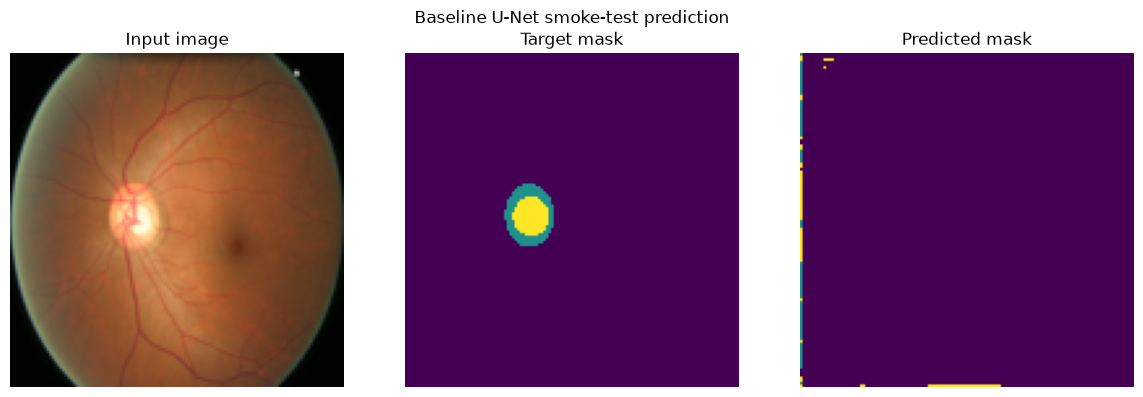

,artifact,path,exists
0,prediction visualization,reports/figures/baseline_unet_smoke_test_prediction.png,True


In [17]:
# 03.17 — Optional prediction visualization

model.eval()

val_batch = next(iter(loaders.val))

with torch.no_grad():
    val_images = val_batch["image"].to(device).float()
    val_masks = val_batch["mask"].to(device).long()
    val_logits = model(val_images)
    val_preds = torch.argmax(val_logits, dim=1)

image_np = val_images[0].detach().cpu().permute(1, 2, 0).numpy()
target_np = val_masks[0].detach().cpu().numpy()
pred_np = val_preds[0].detach().cpu().numpy()

figure_path = FIGURES_DIR / "baseline_unet_smoke_test_prediction.png"

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image_np)
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(target_np, vmin=0, vmax=2)
axes[1].set_title("Target mask")
axes[1].axis("off")

axes[2].imshow(pred_np, vmin=0, vmax=2)
axes[2].set_title("Predicted mask")
axes[2].axis("off")

fig.suptitle("Baseline U-Net smoke-test prediction")
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(
    [
        {
            "artifact": "prediction visualization",
            "path": str(figure_path.relative_to(PROJECT_ROOT)),
            "exists": figure_path.exists(),
        }
    ]
)

In [18]:
# 03.18 — Notebook 03 handoff summary

final_train_result = history_df[history_df["phase"] == "train"].tail(1)
final_val_result = history_df[history_df["phase"] == "val"].tail(1)

handoff_rows = [
    {
        "item": "Combined manifest loaded",
        "status": "READY",
        "evidence": f"{len(manifest)} rows from Notebook 02 combined split manifest",
    },
    {
        "item": "Dataloaders built",
        "status": "READY",
        "evidence": f"train={len(loaders.train.dataset)}, val={len(loaders.val.dataset)}, test={len(loaders.test.dataset)}",
    },
    {
        "item": "Baseline U-Net constructed",
        "status": "READY",
        "evidence": f"{MODEL_NAME} with {ENCODER_NAME}; {trainable_parameters:,} trainable parameters",
    },
    {
        "item": "Training smoke test",
        "status": "READY" if not history_df.empty else "CHECK",
        "evidence": f"{SMOKE_EPOCHS} epoch; train batches={MAX_TRAIN_BATCHES}; val batches={MAX_VAL_BATCHES}",
    },
    {
        "item": "Training outputs saved",
        "status": "READY" if training_summary_path.exists() and training_config_path.exists() else "CHECK",
        "evidence": str(training_summary_path.relative_to(PROJECT_ROOT)),
    },
    {
        "item": "Next notebook",
        "status": "READY",
        "evidence": "Proceed to longer baseline training or Notebook 04 model comparison after confirming Notebook 03 outputs.",
    },
]

handoff_df = pd.DataFrame(handoff_rows)

display(handoff_df)

if not final_train_result.empty:
    display(Markdown("### Final smoke-test train result"))
    display(final_train_result)

if not final_val_result.empty:
    display(Markdown("### Final smoke-test validation result"))
    display(final_val_result)

,item,status,evidence
0,Combined manifest loaded,READY,3358 rows from Notebook 02 combined split manifest
1,Dataloaders built,READY,"train=1911, val=725, test=722"
2,Baseline U-Net constructed,READY,"unet with resnet18; 14,328,499 trainable parameters"
3,Training smoke test,READY,1 epoch; train batches=3; val batches=2
4,Training outputs saved,READY,reports/training/baseline_unet_smoke_test_summary.csv
5,Next notebook,READY,Proceed to longer baseline training or Notebook 04 model comparison after confirming Notebook 03 outputs.


### Final smoke-test train result

,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches
0,train,1,1.697156,0.073571,0.014536,0.465337,6,3,1.338819,3


### Final smoke-test validation result

,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches
1,val,1,1.776657,3.788545e-09,5.690877e-09,0.467407,4,2,0.382367,2


In [19]:
# 03.19 — Longer baseline training configuration

LONG_RUN_NAME = "baseline_unet_resnet18_256px_5epoch"

LONG_EPOCHS = 5
LONG_IMAGE_SIZE = (256, 256)
LONG_BATCH_SIZE = 8 if device.type == "cuda" else 2
LONG_NUM_WORKERS = 2 if device.type == "cuda" else 0

LONG_VALIDATE_PATHS = True
LONG_VALIDATE_MASKS = False

LONG_MODEL_NAME = "unet"
LONG_ENCODER_NAME = "resnet18"
LONG_ENCODER_WEIGHTS = None
LONG_IN_CHANNELS = 3
LONG_NUM_CLASSES = 3

LONG_LEARNING_RATE = 1e-4
LONG_WEIGHT_DECAY = 1e-4

LONG_DICE_WEIGHT = 1.0
LONG_CE_WEIGHT = 1.0

long_baseline_config = {
    "run_name": LONG_RUN_NAME,
    "purpose": "Longer baseline U-Net training run after successful smoke test.",
    "epochs": LONG_EPOCHS,
    "image_size": LONG_IMAGE_SIZE,
    "batch_size": LONG_BATCH_SIZE,
    "num_workers": LONG_NUM_WORKERS,
    "validate_paths": LONG_VALIDATE_PATHS,
    "validate_masks": LONG_VALIDATE_MASKS,
    "model_name": LONG_MODEL_NAME,
    "encoder_name": LONG_ENCODER_NAME,
    "encoder_weights": LONG_ENCODER_WEIGHTS,
    "in_channels": LONG_IN_CHANNELS,
    "classes": LONG_NUM_CLASSES,
    "learning_rate": LONG_LEARNING_RATE,
    "weight_decay": LONG_WEIGHT_DECAY,
    "dice_weight": LONG_DICE_WEIGHT,
    "ce_weight": LONG_CE_WEIGHT,
    "device": str(device),
    "note": (
        "This is the first real baseline training run. It is still not final "
        "model tuning or architecture comparison."
    ),
}

pd.DataFrame([long_baseline_config])

,run_name,purpose,epochs,image_size,batch_size,num_workers,validate_paths,validate_masks,model_name,encoder_name,encoder_weights,in_channels,classes,learning_rate,weight_decay,dice_weight,ce_weight,device,note
0,baseline_unet_resnet18_256px_5epoch,Longer baseline U-Net training run after successful smoke test.,5,"(256, 256)",8,2,True,False,unet,resnet18,None,3,3,0.0001,0.0001,1.0,1.0,cuda,This is the first real baseline training run. It is still not final model tuning or architecture comparison.


In [20]:
# 03.20 — Build longer baseline dataloaders

long_loaders = make_segmentation_dataloaders(
    manifest_path=COMBINED_MANIFEST_PATH,
    batch_size=LONG_BATCH_SIZE,
    image_size=LONG_IMAGE_SIZE,
    num_workers=LONG_NUM_WORKERS,
    validate_paths=LONG_VALIDATE_PATHS,
    validate_masks=LONG_VALIDATE_MASKS,
    pin_memory=(device.type == "cuda"),
)

if not isinstance(long_loaders, SegmentationDataLoaders):
    raise TypeError(f"Expected SegmentationDataLoaders, got {type(long_loaders)!r}")

if long_loaders.train is None or long_loaders.val is None or long_loaders.test is None:
    raise ValueError("Expected train, val, and test dataloaders to be available.")

long_loader_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "dataset_rows": len(long_loaders.train.dataset),
            "batches": len(long_loaders.train),
            "batch_size": long_loaders.train.batch_size,
            "image_size": LONG_IMAGE_SIZE,
            "num_workers": LONG_NUM_WORKERS,
        },
        {
            "split": "val",
            "dataset_rows": len(long_loaders.val.dataset),
            "batches": len(long_loaders.val),
            "batch_size": long_loaders.val.batch_size,
            "image_size": LONG_IMAGE_SIZE,
            "num_workers": LONG_NUM_WORKERS,
        },
        {
            "split": "test",
            "dataset_rows": len(long_loaders.test.dataset),
            "batches": len(long_loaders.test),
            "batch_size": long_loaders.test.batch_size,
            "image_size": LONG_IMAGE_SIZE,
            "num_workers": LONG_NUM_WORKERS,
        },
    ]
)

long_train_batch = next(iter(long_loaders.train))

long_batch_summary = pd.DataFrame(
    [
        {
            "field": "image",
            "shape": tuple(long_train_batch["image"].shape),
            "dtype": str(long_train_batch["image"].dtype),
            "min": float(long_train_batch["image"].min()),
            "max": float(long_train_batch["image"].max()),
            "unique_values": "[continuous]",
        },
        {
            "field": "mask",
            "shape": tuple(long_train_batch["mask"].shape),
            "dtype": str(long_train_batch["mask"].dtype),
            "min": int(long_train_batch["mask"].min()),
            "max": int(long_train_batch["mask"].max()),
            "unique_values": sorted(torch.unique(long_train_batch["mask"]).cpu().tolist()),
        },
    ]
)

display(long_loader_summary)
display(long_batch_summary)

/home/gsr3qz/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


,split,dataset_rows,batches,batch_size,image_size,num_workers
0,train,1911,239,8,"(256, 256)",2
1,val,725,91,8,"(256, 256)",2
2,test,722,91,8,"(256, 256)",2


,field,shape,dtype,min,max,unique_values
0,image,"(8, 3, 256, 256)",torch.float32,0.0,1.0,[continuous]
1,mask,"(8, 256, 256)",torch.int64,0.0,2.0,"[0, 1, 2]"


In [21]:
# 03.21 — Build longer baseline model, loss, optimizer, and forward-pass check

if device.type == "cuda":
    torch.cuda.empty_cache()

long_seed_config = seed_everything(seed=SEED, deterministic=False)

long_model = build_model(
    model_name=LONG_MODEL_NAME,
    encoder_name=LONG_ENCODER_NAME,
    encoder_weights=LONG_ENCODER_WEIGHTS,
    in_channels=LONG_IN_CHANNELS,
    classes=LONG_NUM_CLASSES,
    activation=None,
)

long_total_parameters = sum(parameter.numel() for parameter in long_model.parameters())
long_trainable_parameters = sum(
    parameter.numel() for parameter in long_model.parameters() if parameter.requires_grad
)

long_criterion = DiceCELoss(
    dice_weight=LONG_DICE_WEIGHT,
    ce_weight=LONG_CE_WEIGHT,
)

long_optimizer = torch.optim.AdamW(
    long_model.parameters(),
    lr=LONG_LEARNING_RATE,
    weight_decay=LONG_WEIGHT_DECAY,
)

long_model = long_model.to(device)
long_model.eval()

with torch.no_grad():
    long_sample_images = long_train_batch["image"].to(device).float()
    long_sample_masks = long_train_batch["mask"].to(device).long()
    long_sample_logits = long_model(long_sample_images)
    long_sample_loss = long_criterion(long_sample_logits, long_sample_masks)

long_forward_check = pd.DataFrame(
    [
        {
            "check": "model constructed",
            "status": "OK",
            "value": f"{LONG_MODEL_NAME} with {LONG_ENCODER_NAME}",
        },
        {
            "check": "encoder weights",
            "status": "OK",
            "value": LONG_ENCODER_WEIGHTS,
        },
        {
            "check": "total parameters",
            "status": "OK",
            "value": long_total_parameters,
        },
        {
            "check": "trainable parameters",
            "status": "OK",
            "value": long_trainable_parameters,
        },
        {
            "check": "sample image shape",
            "status": "OK",
            "value": tuple(long_sample_images.shape),
        },
        {
            "check": "sample logits shape",
            "status": "OK"
            if tuple(long_sample_logits.shape)
            == (
                LONG_BATCH_SIZE,
                LONG_NUM_CLASSES,
                LONG_IMAGE_SIZE[0],
                LONG_IMAGE_SIZE[1],
            )
            else "CHECK",
            "value": tuple(long_sample_logits.shape),
        },
        {
            "check": "sample loss",
            "status": "OK" if torch.isfinite(long_sample_loss).item() else "CHECK",
            "value": float(long_sample_loss.detach().cpu()),
        },
    ]
)

long_forward_check

,check,status,value
0,model constructed,OK,unet with resnet18
1,encoder weights,OK,None
2,total parameters,OK,14328499
3,trainable parameters,OK,14328499
4,sample image shape,OK,"(8, 3, 256, 256)"
5,sample logits shape,OK,"(8, 3, 256, 256)"
6,sample loss,OK,1.924746


In [ ]:
# 03.22 — Run longer baseline U-Net training with progress display

from glaucoma_segmentation.training.train_loop import (
    fit_model_with_progress,
    history_to_dicts,
)

long_training_started_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

if device.type == "cuda":
    torch.cuda.empty_cache()

long_history = fit_model_with_progress(
    model=long_model,
    train_loader=long_loaders.train,
    val_loader=long_loaders.val,
    criterion=long_criterion,
    optimizer=long_optimizer,
    device=device,
    epochs=LONG_EPOCHS,
    max_train_batches=None,
    max_val_batches=None,
    run_name=LONG_RUN_NAME,
    image_size=LONG_IMAGE_SIZE,
    batch_size=LONG_BATCH_SIZE,
    print_epoch_summary=True,
    leave_progress=True,
)

long_history_df = pd.DataFrame(history_to_dicts(long_history))
long_training_finished_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

long_history_df

Running baseline_unet_resnet18_256px_5epoch | epoch 01/05 | image_size=(256, 256) | batch_size=8


val epoch 01/05:   0%|          | 0/91 [00:00<?, ?it/s]/home/gsr3qz/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
val epoch 01/05: 100%|██████████| 91/91 [00:40<00:00,  2.25it/s, loss=0.6522, disc=0.547, cup=0.539, cdr_mae=0.187]


Epoch 01/05 complete | train_loss=0.9399 | val_loss=0.6522 | val_disc_dice=0.5472 | val_cup_dice=0.5391 | val_cdr_mae=0.1866 | epoch_time=2.87 min
Running baseline_unet_resnet18_256px_5epoch | epoch 02/05 | image_size=(256, 256) | batch_size=8


val epoch 02/05: 100%|██████████| 91/91 [00:39<00:00,  2.30it/s, loss=0.3291, disc=0.784, cup=0.712, cdr_mae=0.109]


Epoch 02/05 complete | train_loss=0.4522 | val_loss=0.3291 | val_disc_dice=0.7836 | val_cup_dice=0.7125 | val_cdr_mae=0.1090 | epoch_time=2.91 min
Running baseline_unet_resnet18_256px_5epoch | epoch 03/05 | image_size=(256, 256) | batch_size=8


...

val epoch 04/05: 100%|██████████| 91/91 [00:45<00:00,  1.98it/s, loss=0.1709, disc=0.828, cup=0.779, cdr_mae=0.069]


Epoch 04/05 complete | train_loss=0.1939 | val_loss=0.1709 | val_disc_dice=0.8282 | val_cup_dice=0.7791 | val_cdr_mae=0.0695 | epoch_time=3.25 min
Running baseline_unet_resnet18_256px_5epoch | epoch 05/05 | image_size=(256, 256) | batch_size=8


val epoch 05/05: 100%|██████████| 91/91 [00:41<00:00,  2.19it/s, loss=0.1764, disc=0.801, cup=0.746, cdr_mae=0.099]

Epoch 05/05 complete | train_loss=0.1643 | val_loss=0.1764 | val_disc_dice=0.8011 | val_cup_dice=0.7461 | val_cdr_mae=0.0986 | epoch_time=3.18 min


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches
0,train,1,0.939929,0.547686,0.283504,0.293864,1911,239,131.921661,None
1,val,1,0.652241,0.547158,0.539125,0.186633,725,91,40.450320,None
2,train,2,0.452153,0.732248,0.653925,0.124293,1911,239,134.713027,None
3,val,2,0.329109,0.783588,0.712485,0.108957,725,91,39.606779,None
4,train,3,0.256377,0.785549,0.696169,0.104307,1911,239,143.551948,None
5,val,3,0.261163,0.716703,0.715785,0.116869,725,91,44.110864,None
6,train,4,0.193875,0.810846,0.720498,0.096436,1911,239,149.163808,None
7,val,4,0.170890,0.828218,0.779138,0.069471,725,91,45.865527,None
8,train,5,0.164283,0.829170,0.743679,0.087397,1911,239,149.301247,None
9,val,5,0.176383,0.801148,0.746070,0.098554,725,91,41.482242,None


In [24]:
# 03.23 — Save longer baseline training outputs

long_history_path = TRAINING_REPORT_DIR / f"{LONG_RUN_NAME}_training_history.csv"
long_summary_path = TRAINING_REPORT_DIR / f"{LONG_RUN_NAME}_training_summary.csv"

long_history_df.to_csv(long_history_path, index=False)

long_val_df = long_history_df[long_history_df["phase"] == "val"].copy()
long_train_df = long_history_df[long_history_df["phase"] == "train"].copy()

best_val_by_loss = long_val_df.sort_values("loss", ascending=True).head(1).iloc[0]
best_val_by_cdr = long_val_df.sort_values("cdr_mae", ascending=True).head(1).iloc[0]
final_val = long_val_df.sort_values("epoch").tail(1).iloc[0]
final_train = long_train_df.sort_values("epoch").tail(1).iloc[0]

long_training_summary_df = pd.DataFrame(
    [
        {
            "run_name": LONG_RUN_NAME,
            "summary_item": "best_val_loss",
            "epoch": int(best_val_by_loss["epoch"]),
            "loss": float(best_val_by_loss["loss"]),
            "disc_dice": float(best_val_by_loss["disc_dice"]),
            "cup_dice": float(best_val_by_loss["cup_dice"]),
            "cdr_mae": float(best_val_by_loss["cdr_mae"]),
            "n_images": int(best_val_by_loss["n_images"]),
            "n_batches": int(best_val_by_loss["n_batches"]),
            "elapsed_seconds": float(best_val_by_loss["elapsed_seconds"]),
        },
        {
            "run_name": LONG_RUN_NAME,
            "summary_item": "best_val_cdr_mae",
            "epoch": int(best_val_by_cdr["epoch"]),
            "loss": float(best_val_by_cdr["loss"]),
            "disc_dice": float(best_val_by_cdr["disc_dice"]),
            "cup_dice": float(best_val_by_cdr["cup_dice"]),
            "cdr_mae": float(best_val_by_cdr["cdr_mae"]),
            "n_images": int(best_val_by_cdr["n_images"]),
            "n_batches": int(best_val_by_cdr["n_batches"]),
            "elapsed_seconds": float(best_val_by_cdr["elapsed_seconds"]),
        },
        {
            "run_name": LONG_RUN_NAME,
            "summary_item": "final_train_epoch",
            "epoch": int(final_train["epoch"]),
            "loss": float(final_train["loss"]),
            "disc_dice": float(final_train["disc_dice"]),
            "cup_dice": float(final_train["cup_dice"]),
            "cdr_mae": float(final_train["cdr_mae"]),
            "n_images": int(final_train["n_images"]),
            "n_batches": int(final_train["n_batches"]),
            "elapsed_seconds": float(final_train["elapsed_seconds"]),
        },
        {
            "run_name": LONG_RUN_NAME,
            "summary_item": "final_val_epoch",
            "epoch": int(final_val["epoch"]),
            "loss": float(final_val["loss"]),
            "disc_dice": float(final_val["disc_dice"]),
            "cup_dice": float(final_val["cup_dice"]),
            "cdr_mae": float(final_val["cdr_mae"]),
            "n_images": int(final_val["n_images"]),
            "n_batches": int(final_val["n_batches"]),
            "elapsed_seconds": float(final_val["elapsed_seconds"]),
        },
    ]
)

long_training_summary_df.to_csv(long_summary_path, index=False)

saved_long_outputs_df = pd.DataFrame(
    [
        {
            "artifact": "long baseline training history",
            "path": str(long_history_path.relative_to(PROJECT_ROOT)),
            "exists": long_history_path.exists(),
        },
        {
            "artifact": "long baseline training summary",
            "path": str(long_summary_path.relative_to(PROJECT_ROOT)),
            "exists": long_summary_path.exists(),
        },
    ]
)

display(saved_long_outputs_df)
display(long_training_summary_df)

,artifact,path,exists
0,long baseline training history,reports/training/baseline_unet_resnet18_256px_5epoch_training_history.csv,True
1,long baseline training summary,reports/training/baseline_unet_resnet18_256px_5epoch_training_summary.csv,True


,run_name,summary_item,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds
0,baseline_unet_resnet18_256px_5epoch,best_val_loss,4,0.170890,0.828218,0.779138,0.069471,725,91,45.865527
1,baseline_unet_resnet18_256px_5epoch,best_val_cdr_mae,4,0.170890,0.828218,0.779138,0.069471,725,91,45.865527
2,baseline_unet_resnet18_256px_5epoch,final_train_epoch,5,0.164283,0.829170,0.743679,0.087397,1911,239,149.301247
3,baseline_unet_resnet18_256px_5epoch,final_val_epoch,5,0.176383,0.801148,0.746070,0.098554,725,91,41.482242


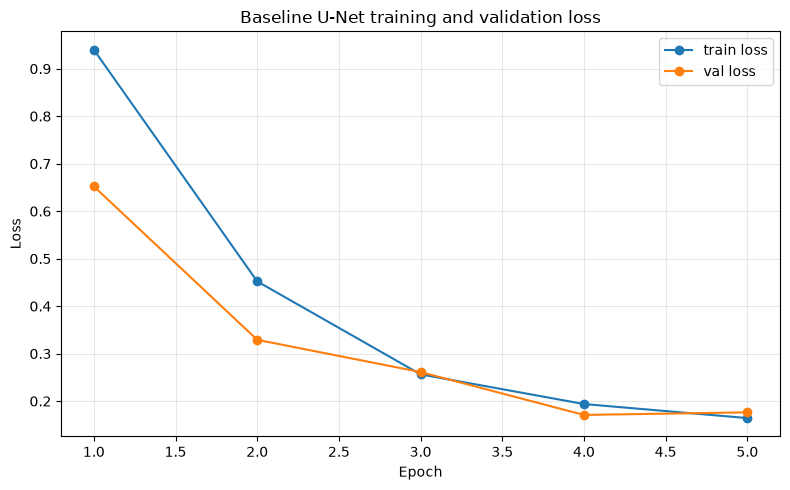

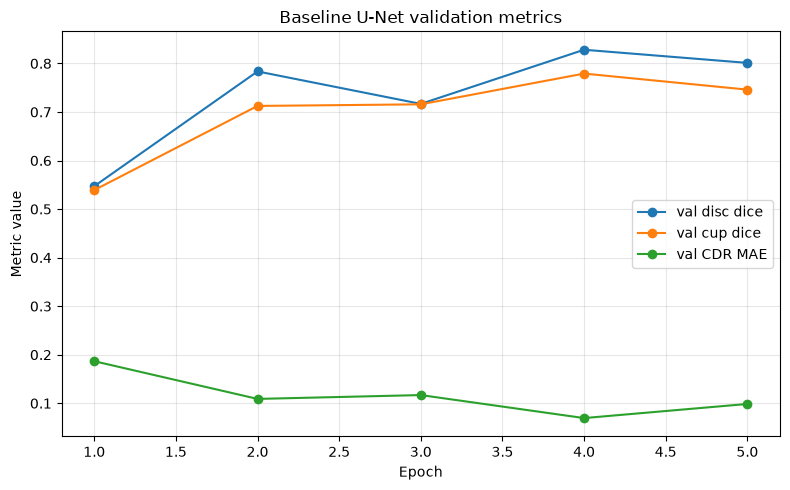

,artifact,path,exists
0,loss curve,reports/figures/baseline_unet_resnet18_256px_5epoch_loss_curve.png,True
1,validation metrics curve,reports/figures/baseline_unet_resnet18_256px_5epoch_validation_metrics.png,True


In [25]:
# 03.24 — Plot longer baseline training curves

plot_df = long_history_df.copy()

train_curve = plot_df[plot_df["phase"] == "train"].sort_values("epoch")
val_curve = plot_df[plot_df["phase"] == "val"].sort_values("epoch")

loss_curve_path = FIGURES_DIR / f"{LONG_RUN_NAME}_loss_curve.png"

plt.figure(figsize=(8, 5))
plt.plot(train_curve["epoch"], train_curve["loss"], marker="o", label="train loss")
plt.plot(val_curve["epoch"], val_curve["loss"], marker="o", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline U-Net training and validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()

dice_curve_path = FIGURES_DIR / f"{LONG_RUN_NAME}_validation_metrics.png"

plt.figure(figsize=(8, 5))
plt.plot(val_curve["epoch"], val_curve["disc_dice"], marker="o", label="val disc dice")
plt.plot(val_curve["epoch"], val_curve["cup_dice"], marker="o", label="val cup dice")
plt.plot(val_curve["epoch"], val_curve["cdr_mae"], marker="o", label="val CDR MAE")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Baseline U-Net validation metrics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(dice_curve_path, dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(
    [
        {
            "artifact": "loss curve",
            "path": str(loss_curve_path.relative_to(PROJECT_ROOT)),
            "exists": loss_curve_path.exists(),
        },
        {
            "artifact": "validation metrics curve",
            "path": str(dice_curve_path.relative_to(PROJECT_ROOT)),
            "exists": dice_curve_path.exists(),
        },
    ]
)

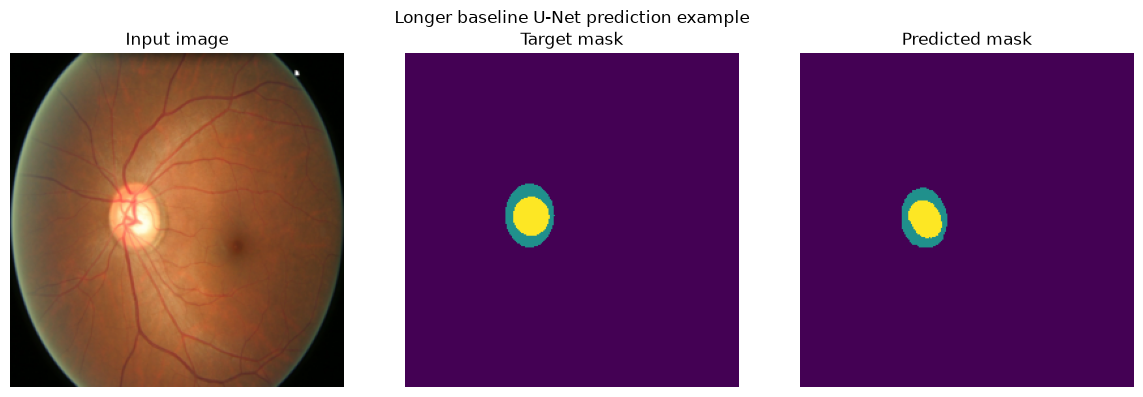

,artifact,path,exists
0,long baseline prediction visualization,reports/figures/baseline_unet_resnet18_256px_5epoch_prediction_example.png,True


In [26]:
# 03.25 — Longer baseline prediction visualization

long_model.eval()

long_val_batch = next(iter(long_loaders.val))

with torch.no_grad():
    long_val_images = long_val_batch["image"].to(device).float()
    long_val_masks = long_val_batch["mask"].to(device).long()
    long_val_logits = long_model(long_val_images)
    long_val_preds = torch.argmax(long_val_logits, dim=1)

long_image_np = long_val_images[0].detach().cpu().permute(1, 2, 0).numpy()
long_target_np = long_val_masks[0].detach().cpu().numpy()
long_pred_np = long_val_preds[0].detach().cpu().numpy()

long_prediction_path = FIGURES_DIR / f"{LONG_RUN_NAME}_prediction_example.png"

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(long_image_np)
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(long_target_np, vmin=0, vmax=2)
axes[1].set_title("Target mask")
axes[1].axis("off")

axes[2].imshow(long_pred_np, vmin=0, vmax=2)
axes[2].set_title("Predicted mask")
axes[2].axis("off")

fig.suptitle("Longer baseline U-Net prediction example")
fig.tight_layout()
fig.savefig(long_prediction_path, dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(
    [
        {
            "artifact": "long baseline prediction visualization",
            "path": str(long_prediction_path.relative_to(PROJECT_ROOT)),
            "exists": long_prediction_path.exists(),
        }
    ]
)

In [27]:
# 03.26 — Final Notebook 03 handoff summary

best_val_epoch = int(best_val_by_loss["epoch"])

final_handoff_rows = [
    {
        "item": "Combined manifest handoff",
        "status": "READY",
        "evidence": f"{len(manifest)} rows loaded from Notebook 02 combined split manifest",
    },
    {
        "item": "Dataloader smoke test",
        "status": "READY",
        "evidence": f"Smoke-test loaders built at {IMAGE_SIZE}; train={len(loaders.train.dataset)}, val={len(loaders.val.dataset)}, test={len(loaders.test.dataset)}",
    },
    {
        "item": "Baseline U-Net smoke test",
        "status": "READY",
        "evidence": "One-epoch limited-batch smoke test completed and saved.",
    },
    {
        "item": "Longer baseline U-Net run",
        "status": "READY",
        "evidence": f"{LONG_EPOCHS} epochs at {LONG_IMAGE_SIZE}, batch_size={LONG_BATCH_SIZE}",
    },
    {
        "item": "Best validation epoch",
        "status": "READY",
        "evidence": (
            f"epoch={best_val_epoch}; "
            f"val_loss={best_val_by_loss['loss']:.4f}; "
            f"disc_dice={best_val_by_loss['disc_dice']:.4f}; "
            f"cup_dice={best_val_by_loss['cup_dice']:.4f}; "
            f"cdr_mae={best_val_by_loss['cdr_mae']:.4f}"
        ),
    },
    {
        "item": "Training outputs saved",
        "status": "READY",
        "evidence": str(long_history_path.relative_to(PROJECT_ROOT)),
    },
    {
        "item": "Reusable training loop support",
        "status": "READY",
        "evidence": "Progress-enabled helpers added to src/glaucoma_segmentation/training/train_loop.py for future notebooks.",
    },
    {
        "item": "Next notebook",
        "status": "READY",
        "evidence": "Proceed to Notebook 04 model comparison using this baseline as the first reference point.",
    },
]

final_handoff_df = pd.DataFrame(final_handoff_rows)
final_handoff_df

,item,status,evidence
0,Combined manifest handoff,READY,3358 rows loaded from Notebook 02 combined split manifest
1,Dataloader smoke test,READY,"Smoke-test loaders built at (128, 128); train=1911, val=725, test=722"
2,Baseline U-Net smoke test,READY,One-epoch limited-batch smoke test completed and saved.
3,Longer baseline U-Net run,READY,"5 epochs at (256, 256), batch_size=8"
4,Best validation epoch,READY,epoch=4; val_loss=0.1709; disc_dice=0.8282; cup_dice=0.7791; cdr_mae=0.0695
5,Training outputs saved,READY,reports/training/baseline_unet_resnet18_256px_5epoch_training_history.csv
6,Reusable training loop support,READY,Progress-enabled helpers added to src/glaucoma_segmentation/training/train_loop.py for future notebooks.
7,Next notebook,READY,Proceed to Notebook 04 model comparison using this baseline as the first reference point.
